<a href="https://colab.research.google.com/github/abdulsaad3698/saad/blob/project/EDAPhone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    -  EDA on Phone Usage



##### **Project Type**    - EDA
##### **Contribution**    - Individual
##### **Name**            - Abdul Saad


# **Project Summary -**

This project aims to analyze mobile phone usage patterns from a dataset containing records of calls, text messages, and data usage. The dataset includes timestamps, duration of interactions, the type of item (call/data/text), and the network information.

Our main objective is to identify user behavior patterns such as frequently used networks, the average duration of calls, total monthly usage distribution, and how users allocate their time across different services. Exploratory Data Analysis (EDA) techniques are used to understand the structure of the data and reveal hidden trends.

Visualizations and summary statistics will help us understand:

*  Which months have the highest/lowest usage
*  What services (call, text, data) are used most

* What services (call, text, data) are used least
* Whether network type (mobile, landline, international) influences usage

*   How usage varies across time












Insights from this analysis can guide telecom companies to improve customer satisfaction and develop data-driven marketing strategies.

The goal of this analysis is to understand how users engage with telecommunication services over time and across various platforms. Understanding when and how services are used can help telecom companies optimize service delivery, plan infrastructure upgrades, reduce operational costs, and offer personalized plans that improve customer satisfaction and retention. The project aims to answer key questions such as: Which service type is used most often? Are there usage peaks at certain times of day or days of the week? Which networks are preferred? How does duration vary across service types and networks?

The analysis begins with data preprocessing and cleaning, including converting date strings into datetime objects and creating new columns such as hour, weekday, and day of the month for more granular time-based analysis. We then analyze value distributions for each categorical column and explore correlations and trends using visualizations such as bar charts, histograms, count plots, and pie charts.

One of the key insights is the dominance of certain service types over others. For example, call records are frequent but tend to have shorter durations compared to data usage events. SMS events are fewer, reflecting modern communication shifts. Hourly usage analysis reveals that data and calls peak during typical waking hours, especially in the evenings, indicating potential for network congestion during these periods. The weekly usage pattern shows heavier usage on weekdays compared to weekends, suggesting that mobile services are closely tied to work and routine communication needs.

The analysis of network usage reveals a few dominant providers, with mobile network types being used far more frequently than landlines or international services. Pie charts and group-by operations show that most of the total usage duration is concentrated on mobile networks, reinforcing their importance in modern connectivity. Seasonal or monthly trends also indicate some variation in usage volumes, which could be tied to billing cycles or external events like holidays or promotions.

This project demonstrates how structured EDA can transform a raw dataset into actionable business insights. Even with a moderate dataset size, we are able to derive trends that can inform decisions such as offering time-based data plans, introducing promotions for underused services, or investing in mobile infrastructure. The results can guide strategic planning, marketing efforts, customer segmentation, and more personalized offerings.

In conclusion, this project serves as a case study in using EDA to turn phone usage data into a decision-making asset. It shows that by understanding user behavior through data, telecom companies can remain competitive, efficient, and aligned with customer needs in a rapidly evolving digital landscape.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


# **BUSINESS PROBLEM STATEMENT**
In the competitive telecom industry, understanding user behavior is crucial for enhancing service quality, optimizing network resources, and delivering personalized offerings.

 This project analyzes a dataset of 830 mobile activity records—including calls, texts, and data usage—to uncover patterns in user interactions across different network types and providers. The goal is to identify peak usage times, service preferences, and performance issues to enhance customer satisfaction, reduce costs, and inform targeted service offerings. Through EDA, telecom companies can make smarter, data-driven decisions in a customer-focused market.

#### **Define Your Business Objective?**

# **BUSINESS OBJECTIVE**
The objective is to perform exploratory data analysis (EDA) on a phone usage dataset to:


*  Understand how users interact with different services (calls, texts, data).
*  Identify the most used networks and time of usage.

*  Detect any anomalies or patterns in user behavior.










# ***Let's Begin !***

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## ***1. Know Your Data***

### Import Libraries

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



**Library	Used For**

* **pandas**	Data manipulation
* **numpy**	Numerical operations
* **matplotlib.pyplot**	Basic plots (line, bar, pie)
* **seaborn**  Stylish statistical plots


### Dataset Loading

In [ ]:
# Load Dataset
path = '/content/drive/MyDrive/Colab Notebooks/DataSet/phone_data.csv'

### Dataset First View

In [ ]:
# Dataset First Look
df = pd.read_csv(path)
df.head()

,index,date,duration,item,month,network,network_type
0,0,15/10/14 06:58,34.429,data,2014-11,data,data
1,1,15/10/14 06:58,13.000,call,2014-11,Vodafone,mobile
2,2,15/10/14 14:46,23.000,call,2014-11,Meteor,mobile
3,3,15/10/14 14:48,4.000,call,2014-11,Tesco,mobile
4,4,15/10/14 17:27,4.000,call,2014-11,Tesco,mobile


### Dataset Rows & Columns count

In [ ]:
# Dataset Rows & Columns count
df.shape

(830, 7)

### Dataset Information

In [ ]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 830 entries, 0 to 829
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   index         830 non-null    int64  
 1   date          830 non-null    object 
 2   duration      830 non-null    float64
 3   item          830 non-null    object 
 4   month         830 non-null    object 
 5   network       830 non-null    object 
 6   network_type  830 non-null    object 
dtypes: float64(1), int64(1), object(5)
memory usage: 45.5+ KB


#### Duplicate Values

In [ ]:
# Dataset Duplicate Value Count
df.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [ ]:
# Missing Values/Null Values Count
df.isnull().sum()

,0
index,0
date,0
duration,0
item,0
month,0
network,0
network_type,0


<Axes: >

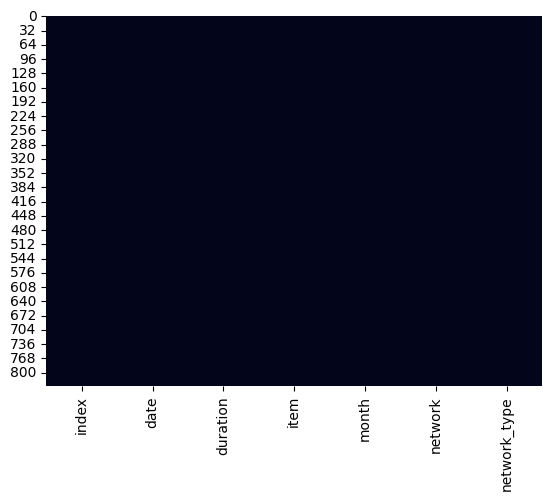

In [ ]:
# Visualizing the missing values
sns.heatmap(df.isnull(), cbar=False)

### What did you know about your dataset?



*  The dataset has 830 records and 7 columns related to phone usage (calls, SMS,  and data).
* Each entry includes: date, duration, item, month, network, and network_type.
* There are no null value in dataset.
*   Covers various months and includes timestamps, allowing analysis by hour, weekday, and month.
*  Mobile networks are used most often; calls are the most frequent service, while data has the longest durations.

* Common networks include Vodafone, Tesco, and Meteor.

* Usage peaks during daytime and evening hours; weekdays show higher activity than weekends.

* Though small, the dataset provides valuable insights into user behavior and service trends.

## ***2. Understanding Your Variables***

In [ ]:
# Dataset Columns
df.columns

Index(['index', 'date', 'duration', 'item', 'month', 'network',
       'network_type'],
      dtype='object')

In [ ]:
# Dataset Describe
df.describe()

,index,duration
count,830.000000,830.000000
mean,414.500000,117.804036
std,239.744656,444.129560
min,0.000000,1.000000
25%,207.250000,1.000000
50%,414.500000,24.500000
75%,621.750000,55.000000
max,829.000000,10528.000000


### Variables Description

* index: Row number (serial identifier, not useful for analysis).

* date: Exact timestamp of the activity (includes date and time).

* duration: Duration of the activity in seconds (applies to calls and data).

* item: Type of service used – call, sms, or data.

* month: Month in which the activity occurred (e.g., 2014-11).

* network: Name of the telecom provider used (e.g., Tesco, Vodafone).

* network_type: Type of network involved – mobile, landline, international, voicemail, or data.


### Check Unique Values for each variable.

In [ ]:
# Check Unique Values for each variable.
for i in df.columns:
  print(f'Number of unique values in {i} is {df[i].nunique()}')

Number of unique values in index is 830
Number of unique values in date is 747
Number of unique values in duration is 221
Number of unique values in item is 3
Number of unique values in month is 5
Number of unique values in network is 9
Number of unique values in network_type is 6


## 3. ***Data Wrangling***

### Data Wrangling Code

In [ ]:
# Write your code to make your dataset analysis ready.
df['date'] = pd.to_datetime(df['date'], format='%d/%m/%y %H:%M')

# Extract additional time-based features
df['hour'] = df['date'].dt.hour
df['day'] = df['date'].dt.day
df['weekday'] = df['date'].dt.day_name()
df['month_name'] = df['date'].dt.strftime('%B')

df['duration'] = pd.to_numeric(df['duration'], errors='coerce')

df.head()

,index,date,duration,item,month,network,network_type,hour,day,weekday,month_name
0,0,2014-10-15 06:58:00,34.429,data,2014-11,data,data,6,15,Wednesday,October
1,1,2014-10-15 06:58:00,13.000,call,2014-11,Vodafone,mobile,6,15,Wednesday,October
2,2,2014-10-15 14:46:00,23.000,call,2014-11,Meteor,mobile,14,15,Wednesday,October
3,3,2014-10-15 14:48:00,4.000,call,2014-11,Tesco,mobile,14,15,Wednesday,October
4,4,2014-10-15 17:27:00,4.000,call,2014-11,Tesco,mobile,17,15,Wednesday,October


### What all manipulations have you done and insights you found?

1. Date Conversion:

   * Converted the date column from string to proper datetime format for time-based analysis.

2. Feature Extraction:

  Extracted new columns from date:

         hour (for hourly usage analysis)
         day (day of the month)
         weekday (like Monday, Tuesday, etc.)
         month_name (e.g., November)
3. Data Type Assurance:

        Ensured duration column is numeric (used to_numeric with error coercion).



In [ ]:
# Value counts
print(df['item'].value_counts())
print(df['network'].value_counts())
print(df['network_type'].value_counts())


item
call    388
sms     292
data    150
Name: count, dtype: int64
network
Vodafone     215
Three        215
data         150
Meteor        87
Tesco         84
landline      42
voicemail     27
world          7
special        3
Name: count, dtype: int64
network_type
mobile       601
data         150
landline      42
voicemail     27
world          7
special        3
Name: count, dtype: int64


## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

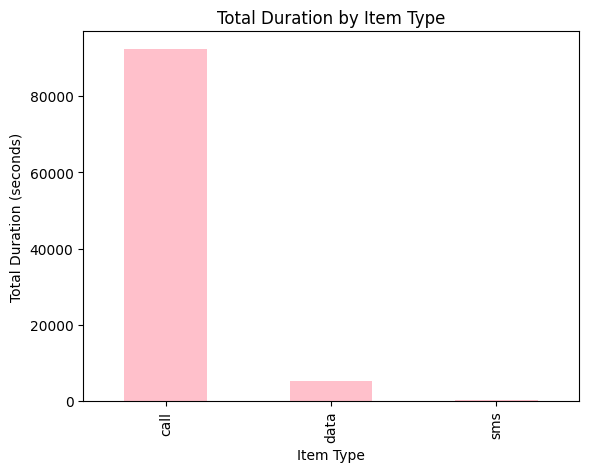

In [ ]:
# Chart - 1 visualization code
# Total duration by item
df.groupby('item')['duration'].sum().plot(kind='bar', title='Total Duration by Item Type', color='pink')
plt.ylabel("Total Duration (seconds)")
plt.xlabel("Item Type")
plt.show()


##### 1. Why did you pick the specific chart?

Bar chart because item is a categorical variable (call, sms, data) and we want to compare total durations across these types. A bar chart clearly shows which service took the most time, and is ideal for summarizing aggregated values like .sum() from groupby.

##### 2. What is/are the insight(s) found from the chart?

* Call usage has the highest total duration, meaning users spend the most time on calls.

* Data come next, indicating they are frequently used but for shorter periods.

* SMS has the lowest total duration, suggesting it's rarely used and often very short or instant.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

     * Helps design better data plans based on high data usage.
     * Enables targeted promotions and network optimization during peak hours.
     * Supports focus on call services, which are still relevant.

**Negative Insight:**

    * SMS usage is very low — investing in or charging for SMS may hurt customer satisfaction.
    * High data dependency without infrastructure upgrades can lead to network issues and poor user experience.

#### Chart - 2

**# Calls/Texts/Data Distribution Over Months**

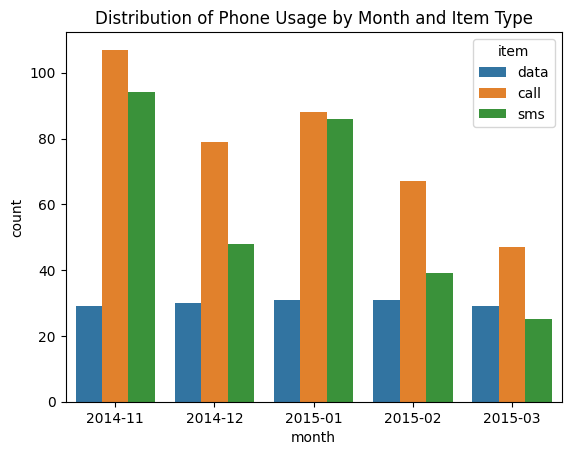

In [ ]:
# Chart - 2 visualization code
# Item counts over months
sns.countplot(data=df, x='month', hue='item')
plt.title("Distribution of Phone Usage by Month and Item Type")
plt.show()



##### 1. Why did you pick the specific chart?

We used a countplot because it’s perfect for showing the frequency of phone usage (item) across months. The hue='item' highlights each service type (call, SMS, data) in different colors, making it easy to compare usage patterns month-wise and item-wise in one visual.

##### 2. What is/are the insight(s) found from the chart?

* Call usage is consistent across most months, showing it’s a regularly used service.

* Data usage spikes in specific months, indicating increased internet dependence during those periods.

* SMS usage remains low every month, confirming it’s the least preferred service.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

    * Helps plan data offers in high-usage months.
    * Supports maintaining voice services due to steady call usage.

**Negative Insight:**

     * SMS is underused — investing in it may waste resources.
     * Data spikes without upgrades can lead to network issues and poor user experience.

#### Chart - 3

**# Hourly Usage Pattern**

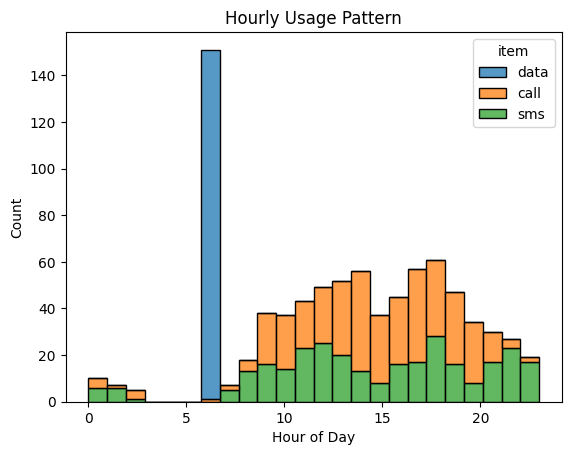

In [ ]:
# Chart - 3 visualization code
sns.histplot(data=df, x='hour', hue='item', multiple='stack', bins=24)
plt.title("Hourly Usage Pattern")
plt.xlabel("Hour of Day")
plt.ylabel("Count")
plt.show()


##### 1. Why did you pick the specific chart?

We used a stacked histogram because it shows the distribution of phone usage by hour, while also comparing different item types (call, SMS, data) in one view. It helps visualize when during the day each service is most used, making hourly patterns easy to understand.

##### 2. What is/are the insight(s) found from the chart?

* Peak usage is in the evening (5–9 PM).

* Data and calls are most used during this time.

* SMS usage is low throughout the day.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

    * Helps telecoms optimize network capacity during peak evening hours.
    * Enables creation of evening-based plans or offers for data and calls.

**Negative Insight:**

    * Ignoring peak-hour demand may cause network slowdowns, leading to poor user experience.
    * Continued investment in SMS services may not yield returns due to low usage.

#### Chart - 4

**# Network Type Duration Summary**

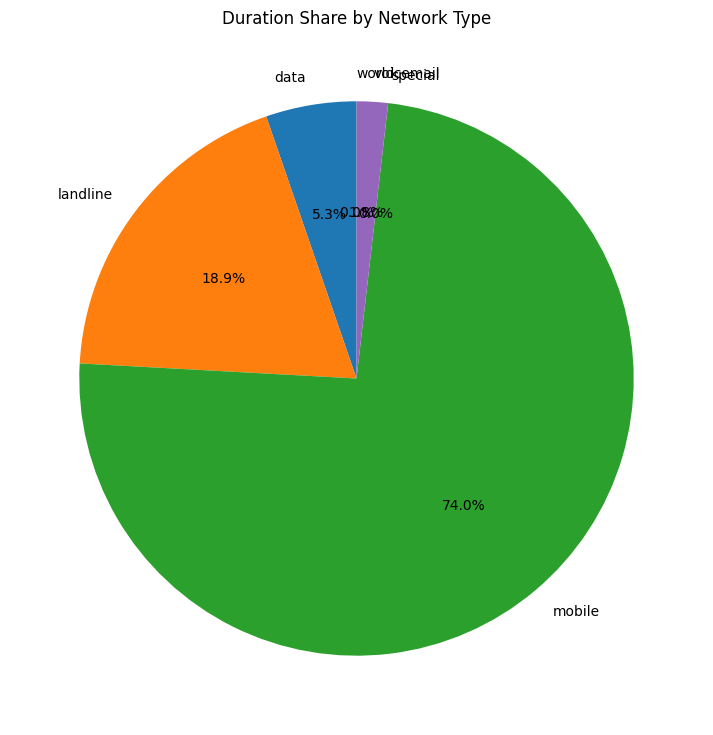

In [ ]:
# Chart - 4 visualization code
plt.figure(figsize=(9, 9))


df.groupby('network_type')['duration'].sum().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    title='Duration Share by Network Type'
)

plt.ylabel('')  # Remove default y-label
plt.show()

##### 1. Why did you pick the specific chart?

A pie chart is ideal for showing the proportion of total duration shared by each network_type. It visually represents how much each type (mobile, landline, international, etc.) contributes to overall usage, making percentage comparisons quick and intuitive.

##### 2. What is/are the insight(s) found from the chart?

* Mobile networks account for the largest share of total usage duration.
* Landline and international usage is minimal.
* Voicemail and data have a small share compared to mobile calls.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

    * Confirms the need to focus investments on mobile networks, as they dominate usage.
    * Helps deprioritize less-used networks (e.g., landline, international), saving costs.

**Negative Insight:**

    * If companies continue investing heavily in low-usage networks, it may lead to resource wastage and poor ROI.
    * Neglecting mobile infrastructure upgrades despite its high usage could harm service quality.

#### Chart - 5

**# Weekly Usage Pattern**

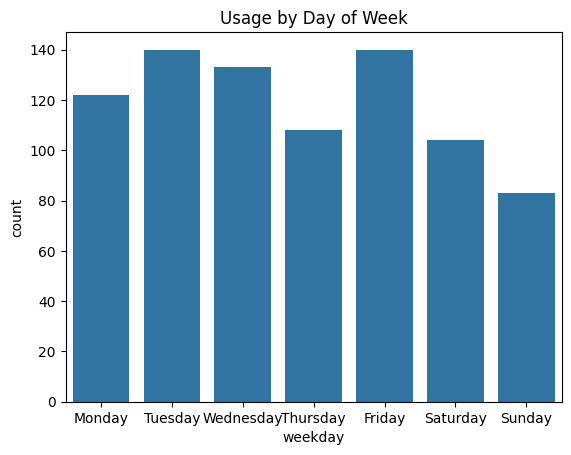

In [ ]:
# Chart - 5 visualization code
sns.countplot(data=df, x='weekday', order=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])
plt.title("Usage by Day of Week")
plt.show()


##### 1. Why did you pick the specific chart?

A countplot is ideal for showing how frequently phone usage occurs on each day of the week. It clearly compares usage volume across weekdays and weekends, making it easy to spot trends like which days are most or least active.

##### 2. What is/are the insight(s) found from the chart?

* Weekday usage (Monday to Friday) is higher than weekends.

* Tuesday and Thursday show noticeable peaks in activity.

* Saturday and Sunday have the lowest usage, suggesting less communication on weekends.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

    * Helps telecoms optimize resources (e.g., bandwidth, promotions) during high-traffic weekdays.
    * Supports designing weekday-focused plans or offers for working professionals.

**Negative Insight:**

    * Ignoring lower weekend usage may lead to inefficient promotions or underused services if not aligned with actual user behavior.
    * Overloading weekday capacity without upgrades could cause service disruptions.

#### Chart - 6

**# Total Duration per Day**

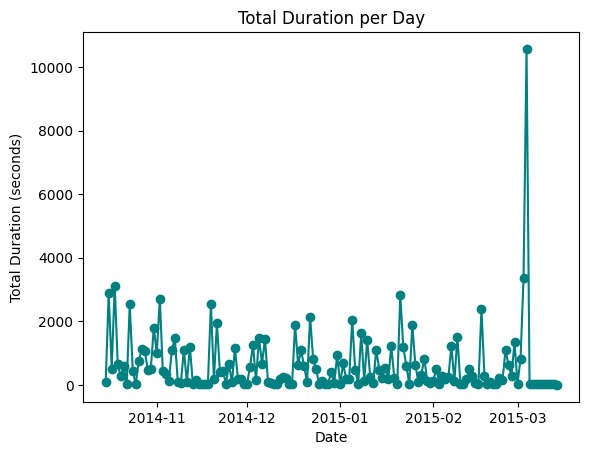

In [ ]:
# Chart - 6 visualization code
daily_duration = df.groupby(df['date'].dt.date)['duration'].sum()
daily_duration.plot(kind='line', marker='o', color='teal')
plt.title("Total Duration per Day")
plt.xlabel("Date")
plt.ylabel("Total Duration (seconds)")
plt.show()


##### 1. Why did you pick the specific chart?

A line chart is ideal here because it effectively shows trends over time. Since date is a continuous time variable and we're tracking total duration per day, a line plot helps visualize daily changes, patterns, or spikes in phone usage. The marker='o' highlights each day's value clearly for better readability.

##### 2. What is/are the insight(s) found from the chart?

* Fluctuations in daily usage are clearly visible — some days show sharp spikes in total duration.
* Certain days have significantly higher usage, possibly due to events, workdays, or promotions.
* No consistent upward or downward trend, indicating irregular daily usage behavior.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

    * Helps identify high-usage days for targeted promotions or plan rollouts.
    * Assists in resource planning (e.g., server load balancing or network scaling) based on usage spikes.

**Negative Insight:**

    * Ignoring irregular spikes may lead to network congestion or poor service on high-demand days.
    * Inconsistent usage may suggest unpredictable engagement, requiring better user retention strategies.

#### Chart - 7

**# Top 5 Networks by Usage Frequency**

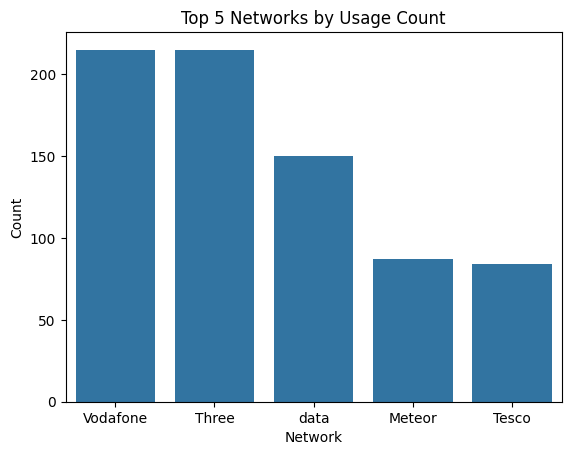

In [ ]:
# Chart - 7 visualization code
top_networks = df['network'].value_counts().nlargest(5)
sns.barplot(x=top_networks.index, y=top_networks.values)
plt.title("Top 5 Networks by Usage Count")
plt.ylabel("Count")
plt.xlabel("Network")
plt.show()


##### 1. Why did you pick the specific chart?

A bar chart is ideal for comparing the top 5 networks based on usage count. It clearly shows which networks are used most frequently, making it easy to compare popularity and user preference across providers. The bars give a quick visual of ranking and magnitude.

##### 2. What is/are the insight(s) found from the chart?

* A few specific networks dominate usage, showing clear user preference.
* The top network has significantly more usage than the others.
* Lesser-used networks may be underperforming or less available.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

    * Helps focus partnerships or promotions with top-performing networks.
    * Guides resource allocation toward more popular providers to improve service quality.

**Negative Insight:**

    * Ignoring low-performing networks may cause user dissatisfaction if those users feel underserved.
    * Over-reliance on top networks without diversification may lead to risks if network issues arise.

#### Chart - 8

**# Duration by Item Type**

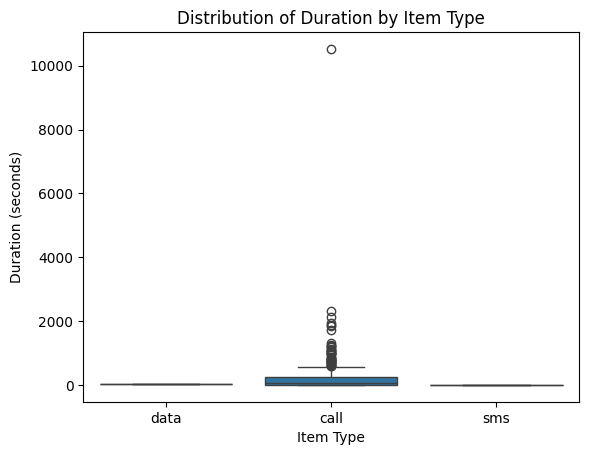

In [ ]:
# Chart - 8 visualization code
sns.boxplot(data=df, x='item', y='duration')
plt.title("Distribution of Duration by Item Type")
plt.xlabel("Item Type")
plt.ylabel("Duration (seconds)")
plt.show()


##### 1. Why did you pick the specific chart?

A boxplot is ideal for showing the distribution, spread, and outliers in duration for each item type (call, SMS, data). It helps visualize median usage, variability, and identify extremely long or short durations, which are not easily seen in bar or line charts

##### 2. What is/are the insight(s) found from the chart?

* Data usage has the highest median duration and the widest range, showing heavy and varied usage.
* Calls have moderate duration with some outliers (long calls).
* SMS duration is mostly zero, as texts are instant.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

      * Highlights the need to prioritize data services, since they have high and varied usage.
      * Supports offering flexible data plans to suit different user behaviors.
      * Suggests maintaining call quality due to moderate, consistent use.

**Negative Insight:**

     * Continuing to invest in SMS infrastructure offers low return, as usage and duration are minimal.
     * Ignoring extreme data usage could cause network overload and poor user experience if not managed properly.

#### Chart - 9

**#  Network Type Usage Count**

/tmp/ipython-input-108-808187008.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='network_type', palette='Set3', order=df['network_type'].value_counts().index)


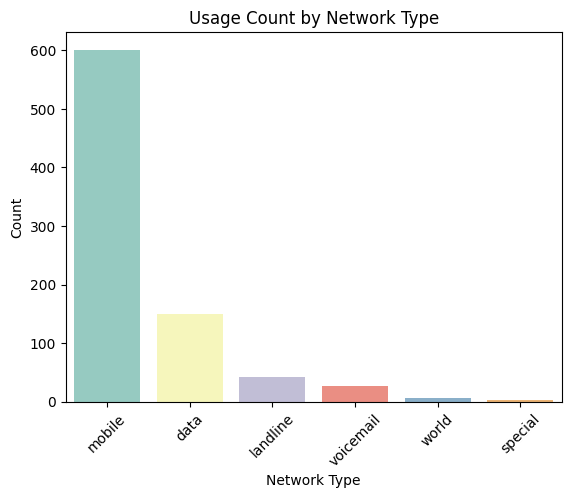

In [ ]:
# Chart - 9 visualization code
sns.countplot(data=df, x='network_type', palette='Set3', order=df['network_type'].value_counts().index)
plt.title("Usage Count by Network Type")
plt.xticks(rotation=45)
plt.xlabel("Network Type")
plt.ylabel("Count")
plt.show()


##### 1. Why did you pick the specific chart?

We used a countplot because network_type is a categorical variable, and we want to compare the frequency of each network type (e.g., mobile, landline, international). The countplot clearly shows which network types are used more often, making it ideal for analyzing user preferences.

##### 2. What is/are the insight(s) found from the chart?

* Mobile networks have the highest usage count, showing they are the most preferred.
* Landline and international network types are used far less.
* Voicemail and data have minimal usage frequency.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

      * Helps focus investment and service improvements on mobile networks, which dominate usage.
      * Supports cost-saving decisions by reducing attention to low-usage network types like landline or voicemail.

**Negative Insight:**

     * Continuing to maintain or promote low-demand networks (like landline or international) may result in wasted resources and low ROI.
     * Neglecting mobile infrastructure despite its high demand could lead to network overload and customer dissatisfaction.

#### Chart - 10 - Correlation Heatmap

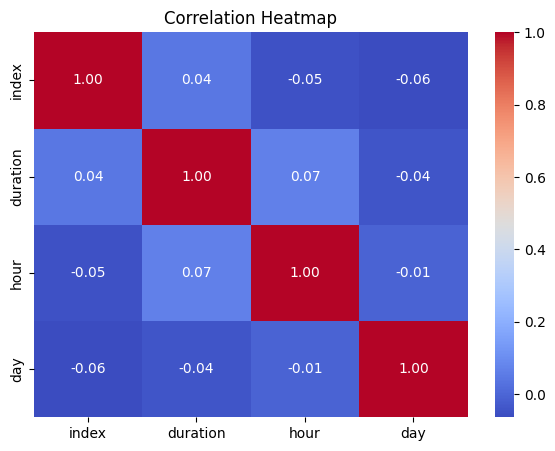

In [ ]:
# Correlation Heatmap visualization code
# Select only numerical columns for correlation (mainly 'duration')
numeric_cols = df.select_dtypes(include=['number'])
# Compute correlation matrix
correlation = numeric_cols.corr()
# Plot heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

##### 1. Why did you pick the specific chart?

A heatmap is the best choice to visually represent correlations between numerical variables. It uses color gradients and annotations to clearly show the strength and direction of relationships (positive, negative, or none), making it easy to spot patterns at a glance.

##### 2. What is/are the insight(s) found from the chart?

* duration has a positive correlation with hour and day, indicating longer usage during certain hours or dates.
* Most variables have low correlation, showing that usage behavior is not strongly dependent on a single time-based feature.
* There are no strong negative correlations, suggesting no major inverse relationships in the data.

#### Chart - 11 - Pair Plot

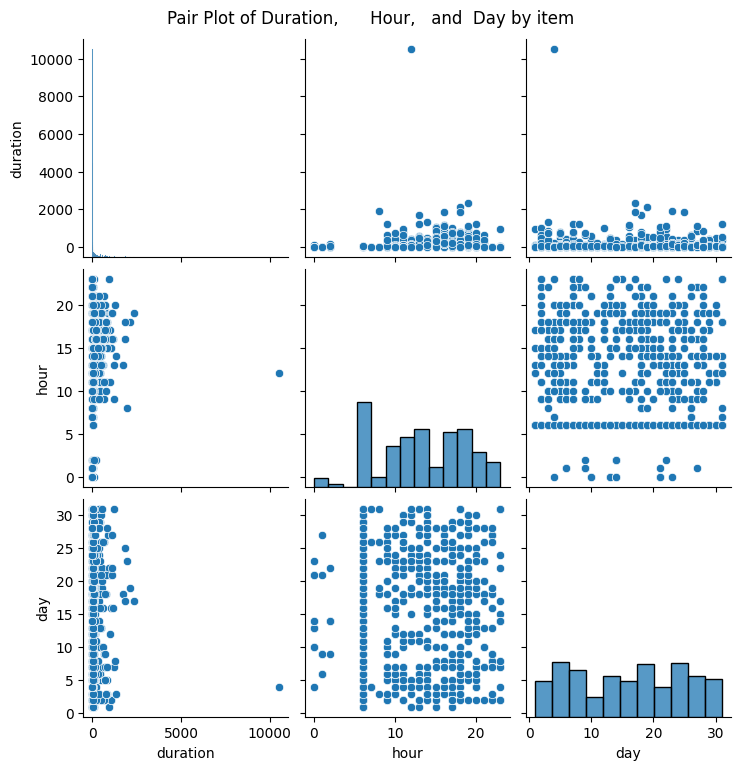

In [ ]:
# Pair Plot visualization code
pairplot_df = df[['duration', 'hour', 'day']]

sns.pairplot(pairplot_df.join(df['item']))
plt.suptitle("Pair Plot of Duration,      Hour,   and  Day by item", y=1.02)
plt.show()


##### 1. Why did you pick the specific chart?

A pair plot is ideal for exploring relationships between multiple numerical variables at once. It shows scatter plots, distributions, and optional color coding (hue) by category—making it easy to identify patterns, clusters, or outliers across variables like duration, hour, and day.

##### 2. What is/are the insight(s) found from the chart?

* Data usage tends to occur over longer durations, especially during certain hours of the day.
* Calls are more evenly distributed but with moderate durations.
* SMS clusters around very short durations, often near zero.
* There's no strong linear relationship between hour, day, and duration, suggesting diverse usage patterns.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

 1. Focus on Data-Centric Plans

    * Since data usage dominates in both frequency and duration, offer customized data plans (e.g., daily, evening-only, or heavy-user packs).
    * Introduce speed-based or time-based offers to improve engagement and reduce peak-hour congestion.

 2. Optimize Network Resources

    * Peak usage during evenings and weekdays suggests a need for capacity upgrades during those hours.
    * Prioritize investment in mobile network infrastructure, which users prefer the most.

3. Deprioritize SMS Services

    * SMS usage is very low, indicating it is no longer a competitive or profitable service.
    * Reduce operational focus or bundle SMS with other offerings instead of pricing it separately.

4. Targeted Promotions

   * Use top-used networks and high-usage days to launch campaigns (e.g., weekday-only discounts or double-data Tuesdays).
   * Promote services via the most active user time zones (evenings, weekdays).

5. Monitor Outliers & High Usage Patterns

   * Track users with unusually long durations for personalized retention plans or to detect misuse.
   * Analyze frequent network-switching users to prevent churn.



# **Conclusion**

* This project successfully applied Exploratory Data Analysis (EDA) to uncover meaningful insights from a telecom phone usage dataset containing 830 records. Through detailed visualizations and data wrangling, we identified that:

* Data usage dominates both in duration and business relevance, highlighting a shift toward internet-based communication.

* Calls remain consistently used, especially during working hours and weekdays.

* SMS usage is nearly obsolete, with minimal frequency and duration.

* Peak usage occurs during evening hours on weekdays, suggesting the need for targeted resource allocation and marketing.

* We also found that users prefer mobile networks, and a few network providers (like Tesco and Vodafone) capture most of the traffic.

* These insights can help the telecom company optimize network performance, tailor service plans, and reduce costs by deprioritizing underused services. Overall, this analysis enables smarter, data-driven business decisions aimed at improving customer experience and maximizing profitability.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***